In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Create generator object
rng = np.random.default_rng(seed=1)
# Generate some test samples
rng.normal(0.8,0.01,10)

array([0.80345584, 0.80821618, 0.80330437, 0.78696843, 0.80905356,
       0.80446375, 0.79463047, 0.80581118, 0.80364572, 0.80294132])

M1: 0.808, M2: 0.797, M3: 0.795


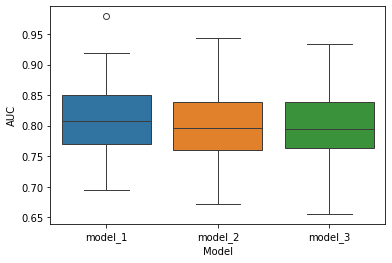

In [9]:
# Standard deviations for the parent and nested intercepts for repeated k fold
parent_sd = 0.02
nested_sd = 0.04
# Standard deviation for performance of all models
sd = 0.02
model_perf = {'model_1':0.81,
              'model_2':0.805,
              'model_3':0.80}
# K fold setup
repeat_count = 15
repeats = range(repeat_count)
folds = range(5)
# List to hold df results
df_list = []
# Loop over the repeats
for repeat in repeats:
    # Sample an intercept for this repeat
    repeat_intercept = rng.normal(0,parent_sd,1)
    #print(repeat,repeat_intercept)
    # Loop over the folds
    for fold in folds:
        unique_id = 1000*repeat + fold
        # Sample a nested intercept
        repeat_fold_intercept = rng.normal(0,nested_sd,1)
        #print('\t',fold,repeat_fold_intercept)
        # Dataframe for recording this fold's results
        iter_df = pd.DataFrame({'id':fold,'id2':repeat,'unid':unique_id},index=[0])
        # Sample model performance
        for model in sorted(model_perf):
            mean_val = repeat_intercept + repeat_fold_intercept + model_perf[model]
            sample = rng.normal(mean_val,sd)
            # Catch for values outside AUC bounds
            if sample>1:
                sample=0.999
            #print('\t\t',model,sample)
            iter_df[model]=sample
        df_list.append(iter_df)
# Concatenate results into a single dataframe
export_df = pd.concat(df_list,ignore_index=True)
export_df.drop(columns=['unid']).to_csv('synthetic_performance_dataframe.csv',index=False)
rename_dict = {'unid':'id'}
export_df.drop(columns=['id','id2']).rename(columns=rename_dict).to_csv('synthetic_performance_dataframe2.csv',index=False)
# Reformat for a plot
plotting_df = export_df.melt(id_vars=['id','id2'],value_vars=['model_1','model_2','model_3'],value_name='AUC',var_name='Model')

# Take a look at the synthetic data
fig,ax= plt.subplots()
sns.boxplot(plotting_df,x='Model',y='AUC',hue='Model',ax=ax)

print("M1: {:.3f}, M2: {:.3f}, M3: {:.3f}".format(export_df.model_1.median(),export_df.model_2.median(),export_df.model_3.median()))

<AxesSubplot:xlabel='Model', ylabel='AUC'>

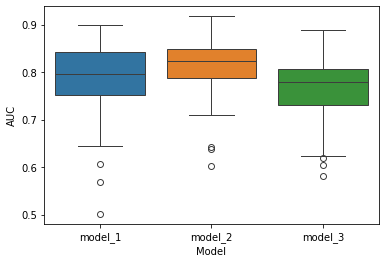

In [27]:
# Logit transformed synthetic data generation

# Standard deviations for the parent and nested intercepts for repeated k fold
parent_sd = 0.1
nested_sd = 0.3
# Standard deviation for performance of all models
sd = 0.2
model_perf = {'model_1':0.8,
              'model_2':0.82,
              'model_3':0.78}
# K fold setup
repeat_count = 15
repeats = range(repeat_count)
folds = range(5)
# List to hold df results
df_list = []
# Loop over the repeats
for repeat in repeats:
    # Sample an intercept for this repeat
    repeat_intercept = rng.normal(0,parent_sd,1)
    #print(repeat,repeat_intercept)
    # Loop over the folds
    for fold in folds:
        unique_id = 1000*repeat + fold
        # Sample a nested intercept
        repeat_fold_intercept = rng.normal(0,nested_sd,1)
        #print('\t',fold,repeat_fold_intercept)
        # Dataframe for recording this fold's results
        iter_df = pd.DataFrame({'id':fold,'id2':repeat,'unid':unique_id},index=[0])
        # Sample model performance
        for model in sorted(model_perf):
            mean_val = repeat_intercept + repeat_fold_intercept + np.log(model_perf[model]/(1-model_perf[model]))
            sample = 1/(1+np.exp(-1*rng.normal(mean_val,sd)))
            #print('\t\t',model,sample)
            iter_df[model]=sample
        df_list.append(iter_df)
# Concatenate results into a single dataframe
export_df = pd.concat(df_list,ignore_index=True)
export_df.to_csv('synthetic_performance_dataframe.csv',index=False)
rename_dict = {'unid':'id'}
export_df.drop(columns=['id','id2']).rename(columns=rename_dict).to_csv('synthetic_performance_dataframe2.csv',index=False)
# Reformat for a plot
plotting_df = export_df.melt(id_vars=['id','id2'],value_vars=['model_1','model_2','model_3'],value_name='AUC',var_name='Model')

# Take a look at the synthetic data
fig,ax= plt.subplots()
sns.boxplot(plotting_df,x='Model',y='AUC',hue='Model',ax=ax)

In [5]:
export_df.head()

,id,id2,unid,model_1,model_2,model_3
0,0,0,0,0.817708,0.819179,0.802795
1,1,0,1,0.835317,0.818673,0.798884
2,2,0,2,0.800444,0.784769,0.806162
3,3,0,3,0.796614,0.803057,0.827342
4,4,0,4,0.797954,0.788027,0.816038


In [85]:
# Alternative nesting structure
rename_dict = {'id':'id2','id2':'id'}
export_df2 = export_df.copy(deep=True).rename(columns=rename_dict)
export_df2.head()

,id2,id,model_1,model_2,model_3
0,0,0,0.856173,0.877524,0.812925
1,1,0,0.813515,0.840657,0.851335
2,2,0,0.834730,0.804677,0.782309
3,3,0,0.853786,0.878536,0.860335
4,4,0,0.866707,0.869228,0.814698


In [86]:
export_df.to_csv('dummy_performance_dataframe_fold_within_repeat.csv',index=False)
export_df2.to_csv('dummy_performance_dataframe_repeat_within_fold.csv',index=False)